In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

In [2]:
import zipfile

zip_path = "opencv-master.zip"
extract_path = "opencv_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
# Path of sample images
image_paths = glob("opencv_dataset/opencv-master/samples/data/*.*")

# Filter only jpg and png
image_paths = [img for img in image_paths if img.endswith(('.jpg', '.png'))]

print("Total Images:", len(image_paths))

# Load first 5 images
for path in image_paths[:5]:
    img = cv2.imread(path)

    if img is not None:
        print(f"\nImage Name: {os.path.basename(path)}")
        print("Shape (H, W, C):", img.shape)

Total Images: 94

Image Name: aero1.jpg
Shape (H, W, C): (480, 640, 3)

Image Name: aero3.jpg
Shape (H, W, C): (480, 640, 3)

Image Name: aloeGT.png
Shape (H, W, C): (1110, 1282, 3)

Image Name: aloeL.jpg
Shape (H, W, C): (1110, 1282, 3)

Image Name: aloeR.jpg
Shape (H, W, C): (1110, 1282, 3)


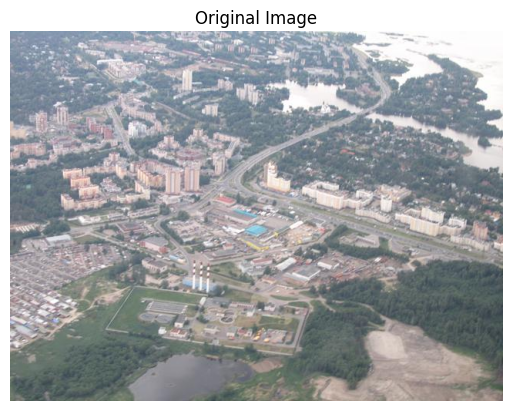

In [4]:
img = cv2.imread(image_paths[0])

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

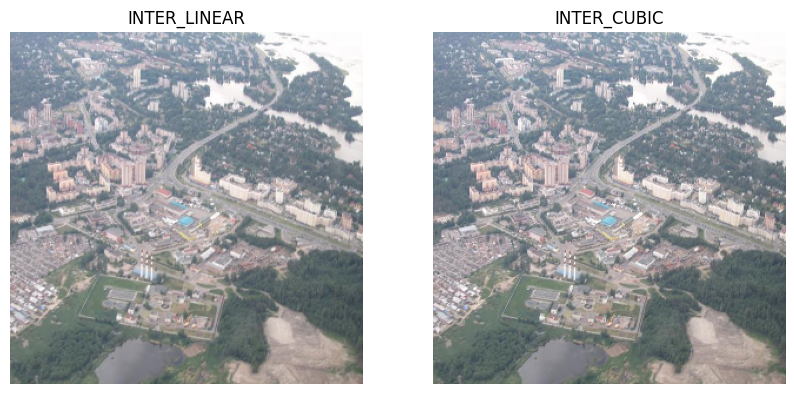

In [5]:

img = cv2.imread(image_paths[0])

# Resize
linear = cv2.resize(img, (300, 300), interpolation=cv2.INTER_LINEAR)
cubic = cv2.resize(img, (300, 300), interpolation=cv2.INTER_CUBIC)

# Convert for display
linear_rgb = cv2.cvtColor(linear, cv2.COLOR_BGR2RGB)
cubic_rgb = cv2.cvtColor(cubic, cv2.COLOR_BGR2RGB)

# Show images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(linear_rgb)
plt.title("INTER_LINEAR")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cubic_rgb)
plt.title("INTER_CUBIC")
plt.axis('off')

plt.show()

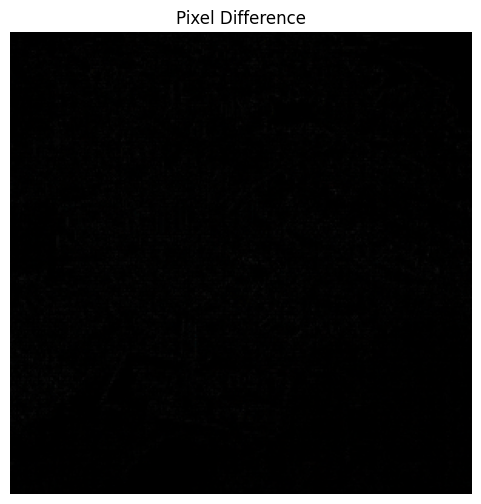

In [6]:
difference = cv2.absdiff(linear, cubic)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(difference, cv2.COLOR_BGR2RGB))
plt.title("Pixel Difference")
plt.axis('off')
plt.show()

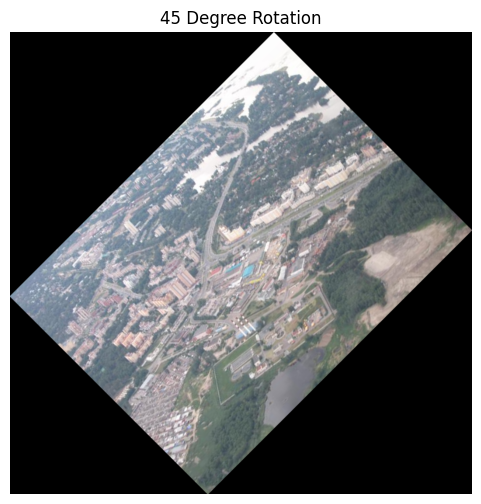

In [7]:
img = cv2.imread(image_paths[0])

(h, w) = img.shape[:2]
center = (w // 2, h // 2)

angle = 45
scale = 1.0

# Rotation matrix
M = cv2.getRotationMatrix2D(center, angle, scale)

# Compute new bounding dimensions
cos = np.abs(M[0, 0])
sin = np.abs(M[0, 1])

new_w = int((h * sin) + (w * cos))
new_h = int((h * cos) + (w * sin))

# Adjust matrix
M[0, 2] += (new_w / 2) - center[0]
M[1, 2] += (new_h / 2) - center[1]

# Rotate image
rotated_45 = cv2.warpAffine(img, M, (new_w, new_h))

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(rotated_45, cv2.COLOR_BGR2RGB))
plt.title("45 Degree Rotation")
plt.axis('off')
plt.show()

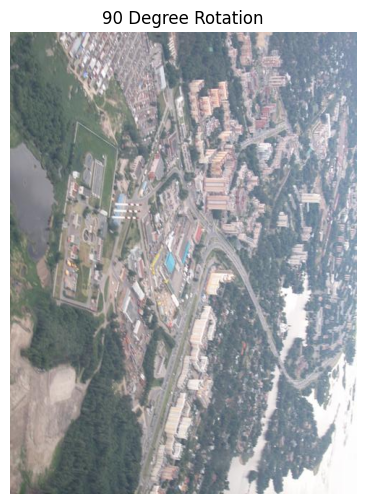

In [8]:
rotated_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(rotated_90, cv2.COLOR_BGR2RGB))
plt.title("90 Degree Rotation")
plt.axis('off')
plt.show()

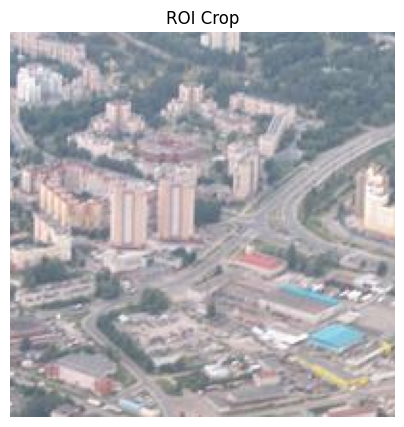

In [9]:
img = cv2.imread(image_paths[0])

# Crop region
roi = img[100:300, 150:350]

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("ROI Crop")
plt.axis('off')
plt.show()

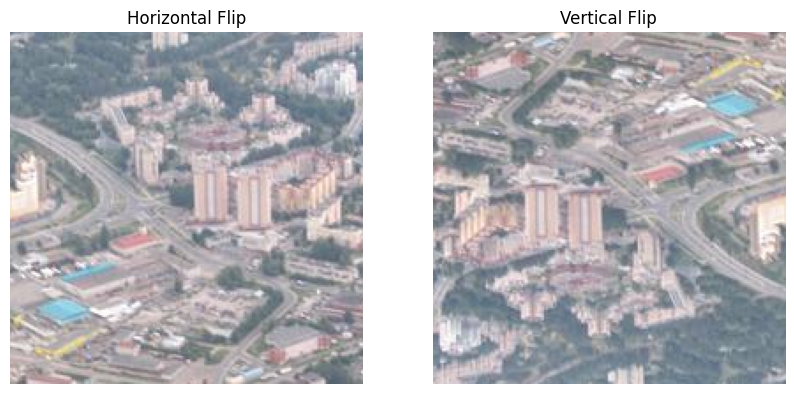

In [10]:
horizontal_flip = cv2.flip(roi, 1)
vertical_flip = cv2.flip(roi, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(horizontal_flip, cv2.COLOR_BGR2RGB))
plt.title("Horizontal Flip")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(vertical_flip, cv2.COLOR_BGR2RGB))
plt.title("Vertical Flip")
plt.axis('off')

plt.show()

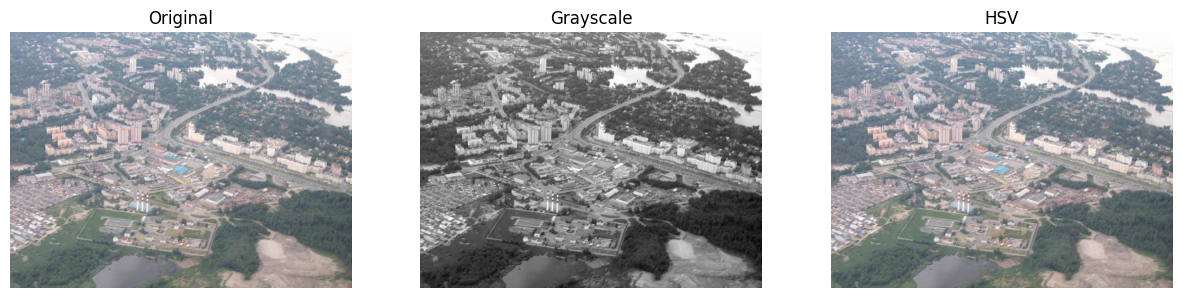

In [11]:
img = cv2.imread(image_paths[0])

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("HSV")
plt.axis('off')

plt.show()

In [12]:
output_folder = "normalized_images"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print("Output Folder Created")

Output Folder Created


In [15]:
target_size = (256, 256)

for path in image_paths:

    # Read image
    img = cv2.imread(path)

    if img is None:
        continue

    # Resize image
    resized = cv2.resize(
        img,
        target_size,
        interpolation=cv2.INTER_AREA
    )

    # Convert to grayscale
    gray = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    # Normalize pixel values
    normalized = cv2.normalize(
        gray,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Save transformed image
    filename = os.path.basename(path)

    save_path = os.path.join(
        output_folder,
        filename
    )

    cv2.imwrite(save_path, normalized)

print("All Images Processed Successfully")

All Images Processed Successfully


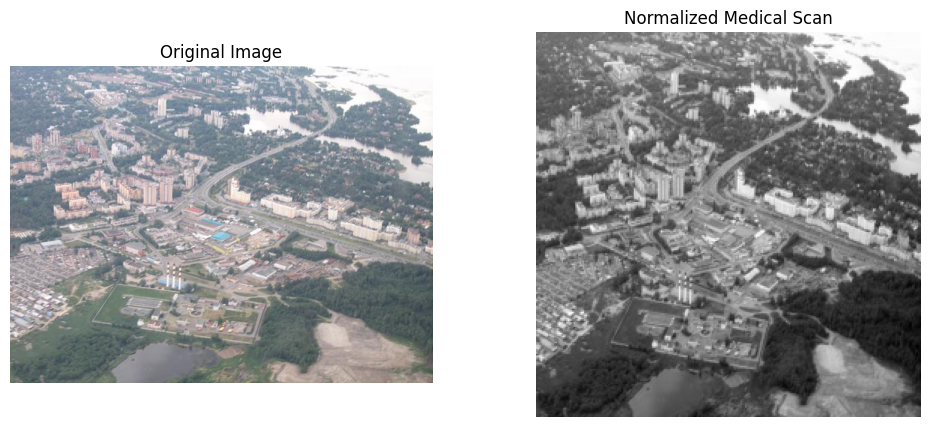

In [16]:
sample_path = image_paths[0]

original = cv2.imread(sample_path)

processed = cv2.imread(
    os.path.join(
        output_folder,
        os.path.basename(sample_path)
    ),
    0
)

plt.figure(figsize=(12,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

# Processed Image
plt.subplot(1,2,2)
plt.imshow(processed, cmap='gray')
plt.title("Normalized Medical Scan")
plt.axis("off")

plt.show()

In [17]:

for file in os.listdir(output_folder)[:5]:

    path = os.path.join(output_folder, file)

    img = cv2.imread(path)

    print(file, ":", img.shape)

aero1.jpg : (256, 256, 3)
aero3.jpg : (256, 256, 3)
aloeGT.png : (256, 256, 3)
aloeL.jpg : (256, 256, 3)
aloeR.jpg : (256, 256, 3)
